# Вариационное исчисление

In [13]:
#all imports here pls
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp

## Простая Житейская задача

Найдём кривую кратчайшей длины между двумя точками в евклидовом пространстве. Для простоты рассмотрим случай $d=2$, но математика показывает, что и там всё так же.

**Шаг 0.** Что такое кривая? Это отображение подмножества $\mathbb{R}$ (для удобства можем взять, например, отрезок $[0,1]$). Конкретнее, каждая координата $x_i(t)=f_i(t)$, где $f_i: \mathbb{R} \to \mathbb{R}^d$.

**Шаг 1.** Что такое длина кривой? Строится через приближение ломаными и взятием подходящего предела, как в интеграле Римана:

$$
L[x] = \int_0^1 \sqrt{\dot{x_1}(t)^2 + .. + \dot{x_d}(t)^2} dt = \int_0^1 F(t,x,\dot{x}) dt.
$$

**Шаг 2.** Соединение двух точек $A$ и $B$ означает $x(0)=A$ и $x(1)=B$.

**Шаг 3.** Задача минимизации:

$$
\min_{x \in \mathcal{M}} L[x],
$$

где $\mathcal{M}$ -- класс кривых где каждая координата $x_i \in C^2[0,1]$ (чтобы вариационное исчисление работало) и ещё $x(0)=A$ и $x(1)=B$.


Считаем вариацию функционала, приравниваем к нулю, получаем необходимое условие экстремума:

$$
F_{x_i} - \frac{d}{dt}F_{\dot{x}_i} = 0, ~~ i=1,..d.
$$

Система дифференциальных уравнений, которая легко решается и даёт $x_i(t)= c^0_i + c^1_i t$, а с подстановкой краевых условий получаем прямой отрезок, соединяющий точки $A$ и $B$. Здесь нам верится, но позже увидим достаточные условия, которые подтвердят, что мы нашли минимум (в определённом смысле).

В случае $d=2$ Система выглядит так:

$$
 \frac{d}{dt}F_{\dot{x}} = 0, ~~ \frac{d}{dt}F_{\dot{y}} = 0,
$$

что можно рассмотреть так: 

$$
\ddot{x}\sqrt{\dot{x}^2 + \dot{y}^2} -\frac{\dot{x}^2\ddot{x}}{\sqrt{\dot{x}^2 + \dot{y}^2}}=0  , \ddot{y}\sqrt{\dot{x}^2 + \dot{y}^2} -\frac{\dot{y}^2\ddot{y}}{\sqrt{\dot{x}^2 + \dot{y}^2}}=0.
$$

Покрутим ещё:
$$
\dot{y}^2 =0  , \dot{x}^2 =0.
$$

По краевым не подходит, но при сокращении мы потеряли решение $\ddot{x}=0, \ddot{y}=0$, именно оно и даст итоговое решение.

Поскольку мы получили систему двух уравнений второго порядка, фазовое пространство 4-мерное и состоит из двух координат $x,y$ и двух скоростей $v_x,v_y$. Посмотрим на фазовую диаграмму получившейся системы, нарисовав её в двух плоскостях -- для $x$ и $y$.


In [14]:
#previously in Dynopt..

# tech, skip it
def toTuple(UV):
    print(UV.shape)
    return UV[...,0], UV[...,1]
def fromTuple(UVtuple):
    print(UVtuple[0].shape)
    return np.concatenate([UVtuple[0][...,None],UVtuple[1][...,None]],axis=-1)

def makeStreamPlot(xx,vv,f,title="",xlabel="X",ylabel="Y",density=0.6):
    XVMesh = np.meshgrid(xx,vv)
    U, V = toTuple(f(0,fromTuple(XVMesh)))
  
    fig, ax = plt.subplots()

    ax.grid()
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)

    ax.streamplot(xx,vv, U, V, density=density, color='k', linewidth=0.7)

    return fig,ax

In [ ]:
omSq = 0.5
def fLineX(t,x):
    '''
    Assumed x[0] = x, x[1]=v_x
    '''
    res = np.zeros_like(x)
    res[...,0]=x[...,1]
    return res
def fLineY(t,y):
    '''
    Assumed y[0] = y, y[1]=v_y
    '''
    res = np.zeros_like(y)
    res[...,0]=y[...,1]
    return res

In [ ]:
xs = np.linspace(-3, 3, 10)
vs = np.linspace(-3, 3, 10)
f,ax = makeStreamPlot(xs,vs, fLineX, 
                      title=f"X",
                      xlabel="X",
                      ylabel="Vx")

f2,ax2 = makeStreamPlot(xs,vs, fLineY, 
                      title=f"Y",
                      xlabel="Y",
                      ylabel="Vy")

Вполне логично: с положительной скоростью частицу толкают в фиксированном направлении. Оно вычисляется из краевых условий. Ещё удобнее посмотреть в осях $X,Y$, для разных значений $V_x,V_y$. Всегда будут получаться прямые.

In [ ]:
def fLineXY(t,x,vx,vy):
    '''
    Assumed x[0] = x, x[1] = y
    '''
    res = np.ones_like(x)
    res[...,0]=res[...,0]*vx
    res[...,1]=res[...,1]*vy
    return res

vx=2
vy=3
def lineXYHandler(t,x):
    return fLineXY(t,x,vx,vy)
xs = np.linspace(-3, 3, 10)
ys = np.linspace(-3, 3, 10)
f,ax = makeStreamPlot(xs,ys, lineXYHandler, 
                      title=f"Space, Vx={vx}, Vy={vy}",
                      xlabel="X",
                      ylabel="Y")



Диаграммы иллюстрируют два факта: скорость не меняется со временем, а координата изменяется в направлении скорости, давая прямую траекторию. Из всех таких экстремальных прямых мы выбираем одну, которая соответствует краевым условиям
.

## Брахистохрона

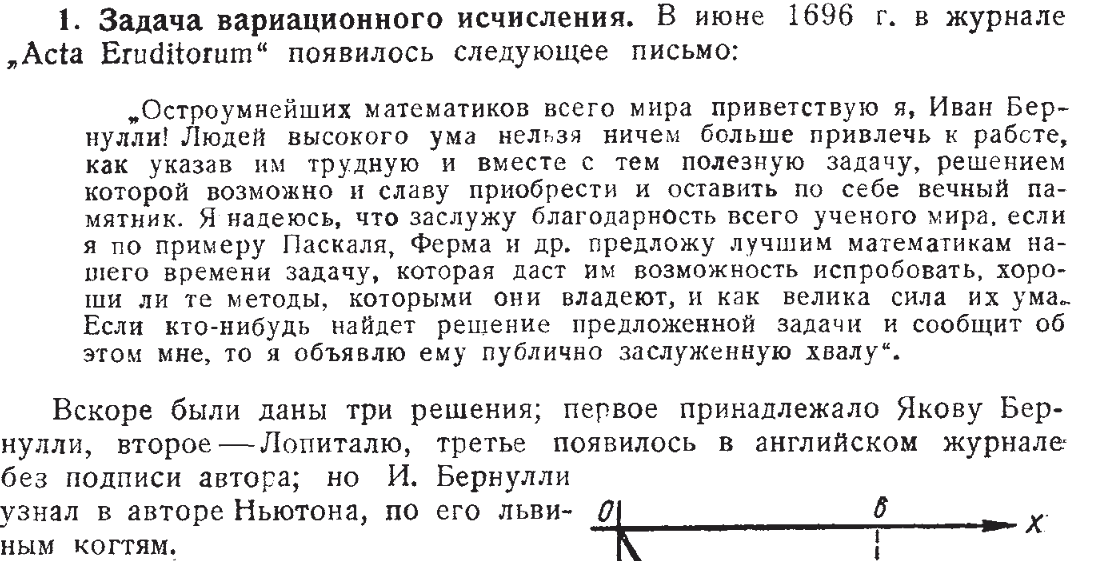

С этого фрагмента начинается знаменитый учебник Н.М. Гюнтера, вышедший в 1941 г по мотивам его курса лекций, который он читал в Ленинграде. Бернулли по жизни занимались не только математикой, это было в основном их увлечение, конкретно Иоганн Бернулли внёс вклад в исследование дифференциальных уравнений и вариационного исчисления.

Задача о брахистохроне является классической и достаточно необычной задачей механики, которую в её более  сложных постановках исследуют до сих пор.

Классическая задача, о которой идёт речь выше состоит в следующем. В предположении того, что тело (материальная точка) скатывается по склону $(x(t),y(t))$ не отрываясь от него (то есть без подлёта на кочке, например), нужно определить форму склона, при которой из точки $A$ тело быстрее всего скатится в точку $B$. По форме задача допускает несколько подходов к решению, мы примем один конкретный. В частности: 

1. форму склона будем задавать функцией $y=f(x)$, то есть параметризация кривой будет по сути $x(t)=t, y(t) = f(x(t))$;
2. Примем ось $Y$ направлением вниз (как в компьютерной графике), стартовое положение тела $x=0,y=0$, конечное положение $x=b,y=h$.

** ВЫВОД УРАВНЕНИЙ ОБСУДИЛИ НА ДОСКЕ**

Получили уравнение

$$
y(1+y'^2)=C,
$$
где $C$ -- константа, которую нужно ещё определить из краевых условий. Это уравнение первого порядка, если переписать, то получим

$$
y' = \pm \sqrt{\frac{C-y}{y}}.
$$

Из фазовых диаграмм можем примерно понять, как может выглядеть такая кривая при разных $C$. В нашей параметризации $y>0$, помним об этом, потому что корень не везде возьмётся действительный. Рассмотрим две ветви корня.

In [15]:
C = 7
def fBrach(t,y):
    return np.concatenate([np.ones_like(y)[...,0:1], np.sqrt(((C-y)/y)) [...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality

(700, 100)
(700, 100, 2)


C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\3707409117.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.concatenate([np.ones_like(y)[...,0:1], np.sqrt(((C-y)/y)) [...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality
C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\3707409117.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.concatenate([np.ones_like(y)[...,0:1], np.sqrt(((C-y)/y)) [...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality


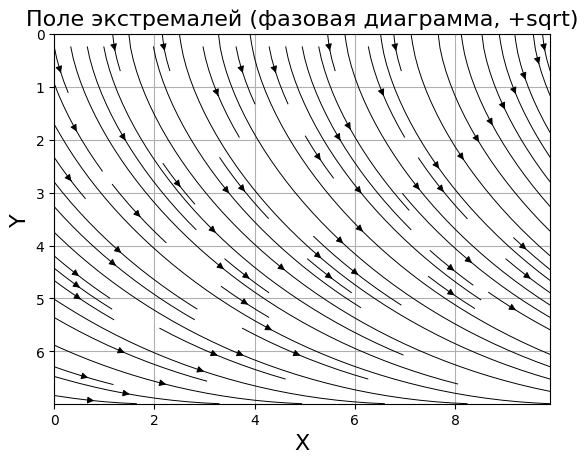

In [16]:
#remember the fish
xx = np.arange(0, 10, 0.1)
yy = np.arange(0, C, 0.01)
f,ax = makeStreamPlot(xx,yy,fBrach, title=f"Поле экстремалей (фазовая диаграмма, +sqrt)",
                      xlabel="X", ylabel="Y", density=1.05)
ax.yaxis.set_inverted(True)
plt.show()

Подходящая кривая называется циклоидой, для её однозначного определения нужно задать время спуска $T$ (на самом деле, его мы и минимизировали), которое определяет область параметров $[0,T]$, а также константу $С$.

$$
y(t) = C sin^2(t),~~ x(t)=C(t-\frac{1}{2}\sin (2t)), ~~ t \in [0,T].
$$

(700, 100)
(700, 100, 2)


C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\3707409117.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.concatenate([np.ones_like(y)[...,0:1], np.sqrt(((C-y)/y)) [...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality
C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\3707409117.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.concatenate([np.ones_like(y)[...,0:1], np.sqrt(((C-y)/y)) [...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality


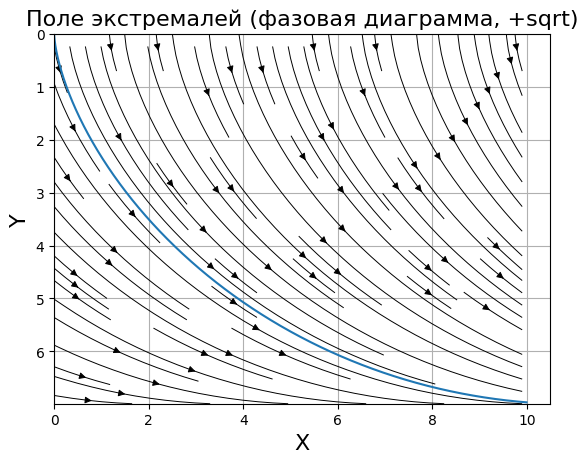

In [17]:
T=1.5
ts = np.arange(0,T,0.001)
curveX = C* (ts - 0.5*np.sin(2*ts))
curveY = C*np.sin(ts)**2

xx = np.arange(0, 10, 0.1)
yy = np.arange(0, C, 0.01)
f,ax = makeStreamPlot(xx,yy,fBrach, title=f"Поле экстремалей (фазовая диаграмма, +sqrt)",
                      xlabel="X", ylabel="Y", density=1.05)
ax.plot(curveX,curveY)
ax.yaxis.set_inverted(True)
plt.show()

Найдём теперь $T$ и $C$ для заданных начальных условий. Заметим, что нам нужно решение $T>0$, тогда из уравнений

$$
C(T-\frac{1}{2}sin(2T) ) = b, ~~ C sin^2(T) = h,
$$

можно попробовать получить $T$, решив

$$
sin^2(T) = (T-\frac{1}{2}sin(2T) ) \frac{h}{b}
$$

и потом найти

$$
C = \frac{h}{sin^2(T)}.
$$

Естественно, придётся численно.

Если идти напрямую от уравнения Эйлера, то от этой проблемы тоже не уйти -- нужно решать краевую задачу для дифференциального уравнения, но об этом позже.

In [18]:
h=5
b=7
def eqFsolve(T):
    return np.sin(T)**2 - (T - 0.5*np.sin(2*T))* (h/b)

T = scp.optimize.fsolve(eqFsolve, [2])
C = h/ np.sin(T)**2
print(f"T={T}, C={C}")

T=[1.47929942], C=[5.04209315]


C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\2910227223.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ts = np.arange(0,T,0.001)
C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\2910227223.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yy = np.arange(0, C, 0.01)
C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\3707409117.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.concatenate([np.ones_like(y)[...,0:1], np.sqrt(((C-y)/y)) [...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality
C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_17960\3707409117.py:3: RuntimeWarning: invalid value enc

(505, 100)
(505, 100, 2)


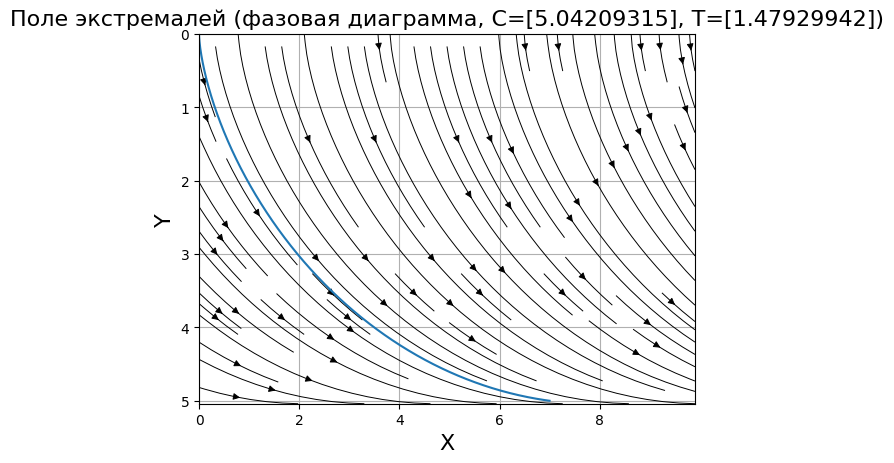

In [19]:
ts = np.arange(0,T,0.001)
curveX = C* (ts - 0.5*np.sin(2*ts))
curveY = C*np.sin(ts)**2

xx = np.arange(0, 10, 0.1)
yy = np.arange(0, C, 0.01)
f,ax = makeStreamPlot(xx,yy,fBrach, title=f"Поле экстремалей (фазовая диаграмма, C={C}, T={T})",
                      xlabel="X", ylabel="Y", density=1.05)
ax.plot(curveX,curveY)
ax.yaxis.set_inverted(True)
plt.show()

У Р А